# Import needed packages

In [7]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'
import torch
import pandas as pd
import torch
import xarray as xr
import numpy as np
from skimage import io, transform
import random
import matplotlib.pyplot as plt
from torchvision import transforms, utils
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn                   # provides classes and functions to create and train neural networks
import torch.nn.functional as F         # provides functions for activation functions, loss functions, and other operations
from sklearn.metrics import confusion_matrix
import seaborn as sns
import re 
import shap 
from sklearn.metrics import balanced_accuracy_score
import pickle
import optuna

# -----------------------------------------------------------------------------
import sys
# Add the path to the 'src' directory (or the root directory of your package)
sys.path.append('..') 
import machine_learning
from machine_learning import convnext_functions


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    torch.use_deterministic_algorithms(True)
    print("Using deterministic algorithms.")
except Exception as e:
    print(f"Could not enforce deterministic algorithms: {e}")

def check_seeds():
    print(f"Torch seed: {torch.initial_seed()}")
    print(f"NumPy seed: {np.random.get_state()[1][0]}")
    print(f"Python random seed: {random.getstate()[1][0]}")
    print(f"CUDA deterministic: {torch.backends.cudnn.deterministic}")
check_seeds()

import gc
import tqdm
import argparse


Using deterministic algorithms.
Torch seed: 3822060012
NumPy seed: 3822060012
Python random seed: 2147483648
CUDA deterministic: True


# Ensemble Results Processing
This code processes ensemble results from multiple model members for extreme event classification.

## Key Features:
* Ensemble Generation: Creates 20 model variants using different random seeds

* Multi-site Processing: Analyzes data for multiple geographical locations

* Dual Input Architecture: Combines local features (NN) and spatial data (CNN)

* Flexible Configuration: Supports both SPEI/SPI drought indices and soil moisture data

* Comprehensive Outputs: Generates both performance metrics and SHAP explainability results

## Output Files:
* Performance Metrics: Accuracy scores and prediction probabilities

* XAI Results: Ensemble-averaged SHAP values with standard deviations

* Text Reports: Detailed accuracy summaries for each

In [8]:

def generate_ensemble_seeds(fixed_seed=123):
    rng = np.random.default_rng(fixed_seed) #generator
    seeds = rng.integers(low=0, high=2**32 - 1, size=20).tolist()
    return seeds

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    g.manual_seed(seed)  # For DataLoader's generator

list_seeds = generate_ensemble_seeds(fixed_seed=123)

import convnext_functions_modifications

sites = ['cordoba', 'stockholm', 'lyon', 'hannover','belgrado'] # All sites!


#File paths large-scale data 
        
file_g500 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_g500_1x1_lagged_standarized_anomalies.nc"
file_g200 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_g200_1x1_lagged_standarized_anomalies.nc"
file_psl = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/std_changed_psl_1x1_lagged_standarized_anomalies.nc"
file_hus850 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/hus850_lagged_standarized_anomalies.nc"
file_hus975 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/hus975_lagged_standarized_anomalies.nc"
file_rsds = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/rsds_lagged_standarized_anomalies.nc"
file_hus700 = "/gpfs/scratch/bsc32/bsc167965/data/era5/lagged_anomalies/hus700_lagged_standarized_anomalies.nc"

# File CO2 data 
file_CO2 = "/home/bsc/bsc167965/TFM/ML/data_files/daily_co2_JJA.nc"

# File local-scale

# ============================================================================================================================
# General Configuration 
# ============================================================================================================================

start_date = "1950-01-01"

variables_era5 = ['g500', 'g200', 'psl'] 
variables_era5land = ['swvl1','swvl2','swvl3']

_ERA5LAND_TRAIN_DATASET_CONF = dict(
    start_date= start_date,
    end_date= "2013-12-31",
    months = [6,7,8],
#    variables = variables_era5land
    )

_ERA5LAND_TEST_DATASET_CONF = dict(
    start_date= "2014-01-01",
    end_date= "2023-12-31",
    months = [6,7,8],
#    variables = variables_era5land
    )

_ERA5_TRAIN_DATASET_CONF = dict(
start_date= start_date,
end_date= "2013-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5
    )

_ERA5_TEST_DATASET_CONF = dict(
start_date= "2014-01-01",
end_date= "2023-12-31",
months = [6,7,8],
start_lag = 1,
lags_era5 = 1,
variables = variables_era5
    )

number_lags = _ERA5_TRAIN_DATASET_CONF['lags_era5']

name_save_CombinedModel = f"CO2_Combinedmodel_trained_with_cnn_nn_trained_together_{number_lags}lags"

# ========================================================================================
# Percentile used in extreme classification 
percentile = '90p'
# ========================================================================================

# ========================================================================================
# SPEI or SPI configuration
using_spei = True
scales_spei = ['30','60']
spei_spi = 'spei'
spei_spi_variable_mapping = {
    'spei': [f'spei_hg_{scale_spei}' for scale_spei in scales_spei],
    'spi': [f'spi_{scale_spei}' for scale_spei in scales_spei]
    }

spei_variables = spei_spi_variable_mapping[spei_spi] # Variable name in the dataset for SPEI
distribution = 'gamma'

# ========================================================================================

# Start loop -------------------------------------------------------------------------------

device = torch.device("cpu")

for site in sites:

    print(f"Doing site : {site}")

    # Local scale data files - SPEI or SPI
    if spei_spi == 'spi':
        files_spei =[f"/gpfs/projects/bsc32/bsc167965/observational_TX/{distribution}_{spei_spi}_tasmax_{site}_{scale_spei}_daily.nc"
                    for scale_spei in scales_spei] # For testing with 1 month scale
    elif spei_spi == 'spei':
        files_spei = [f"/gpfs/projects/bsc32/bsc167965/observational_TX/{distribution}_daily_{spei_spi}{scale_spei}_tasmax_{site}_hg.nc"
                        for scale_spei in scales_spei]

    file_local_scale = f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc"

    # Load datasets --------------------------------------------------------------------------------------------------
    # Large-scale
    train_features_era5 = machine_learning.ERA5Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TRAIN_DATASET_CONF) # shape: features, time, lat, lon 
    test_features_era5 = machine_learning.ERA5Dataset_extremes(file_g500,file_g200,file_psl, **_ERA5_TEST_DATASET_CONF)

    # Local-scale
    if using_spei:
        train_dataset = ERA5LandDataset_extremes_location_spei(file_path=file_local_scale, file_CO2=file_CO2 , files_spei = files_spei, **_ERA5LAND_TRAIN_DATASET_CONF, spei_variables = spei_variables, num_lags=7)
        test_dataset = ERA5LandDataset_extremes_location_spei(file_path=file_local_scale, file_CO2=file_CO2 , files_spei = files_spei, **_ERA5LAND_TEST_DATASET_CONF, spei_variables = spei_variables, num_lags=7)
    
    else:
        train_dataset = machine_learning.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 ,  **_ERA5LAND_TRAIN_DATASET_CONF)
        test_dataset = machine_learning.ERA5LandDataset_extremes_location_swvl_averaged_including_CO2(file_path=f"/gpfs/scratch/bsc32/bsc167965/data/era5_land/lagged_anomalies_and_event_detection/{percentile}_{site}_lagged_standarized_anomalies_and_extreme_detection.nc", file_CO2=file_CO2 ,  **_ERA5LAND_TEST_DATASET_CONF)
        
    # Prepare for ensemble results --------------------------------------------------------------------------------------------------
    outputs_prob_seeds = np.zeros((len(list_seeds),test_dataset.features.shape[0],2))
    ensamble_shap_values_nn_raw = np.zeros((len(list_seeds),test_dataset.features.shape[0],test_dataset.features.shape[1]))
    ensamble_shap_values_cnn_raw = np.zeros((len(list_seeds),test_dataset.features.shape[0],test_features_era5.features.shape[1],58,124))
    
    # Loop over seeds to load models and get results --------------------------------------------------------------------------------
    
    for count_seed,seed in enumerate(list_seeds[:]):         
        
        g = torch.Generator()
        
        reset_seeds(seed)

        # Dataloader configurations --------------------------------------------------------------------------------
         
        _DATALOADERS_CONF = dict(
        batch_size= 32,
        drop_last= False,
        shuffle = True,
        num_workers=0,
        generator=g      
            )
        
        _DATALOADERS_TEST_CONF = dict(
                batch_size= 32,
                drop_last= False,
                shuffle = False,
                num_workers=0
            )
        
        # Combined Dataset and Dataloader -------------------------------------------------------------------------
        
        batch_size = _DATALOADERS_CONF['batch_size'] # batch size for dataloaders both datasets
   
        combined_train_dataset  = machine_learning.CombinedDataset(train_dataset,train_features_era5, variables = variables_era5  )
        combined_test_dataset = machine_learning.CombinedDataset(test_dataset,test_features_era5, variables = variables_era5  )
        
        # Split train and validation
        train_size_combined = int(0.8 * len(combined_train_dataset))
        val_size_combined = len(combined_train_dataset) - train_size_combined
        
        #random split 
        train_subset_combined, val_subset_combined = random_split(combined_train_dataset, [train_size_combined, val_size_combined],generator=g)
        
        # (local,regional,labels)
        combined_train_loader = DataLoader(train_subset_combined, **_DATALOADERS_CONF) # When using DataLoader with shuffle=True, PyTorch randomly picks idx values.
        combined_val_loader = DataLoader(val_subset_combined, **_DATALOADERS_CONF)
        combined_test_loader = DataLoader(combined_test_dataset, **_DATALOADERS_TEST_CONF)
    
        NN_model_loaded = machine_learning.ToCombineExtremeClassifier(input_dim=len(train_dataset.all_features), train_alone_NN=False, num_classes=2).to(device)
        NN_model_loaded.eval()
        reset_seeds(seed)
        CNN_model_loaded = convnext_functions.ConvNext(
               num_channels=len(train_features_era5.all_features),
               num_classes=2,
               patch_size=4,
               layer_dims=[4, 6,6,16],
               depths=[1, 2,2,1],
               drop_rate=0.05,
               train_alone=False,
        ).to(device) 
        reset_seeds(seed)
        
        model = machine_learning.CombinedModel(NN_model_loaded, CNN_model_loaded, nn_hidden_dim=8, cnn_hidden_dim=16,output_dim=2).to(device)
        reset_seeds(seed)
    
        main_path = f'/gpfs/scratch/bsc32/bsc167965/data/test_train_n_shap_dilation/{site}/'

        try: 
            if using_spei:
                with open(os.path.join(main_path, f'1lag_{distribution}_daily_{spei_spi}_{percentile}_results_data_{seed}.pkl'), 'rb') as f:
                    seed_results = pickle.load(f)
                with open(f'/gpfs/scratch/bsc32/bsc167965/data/test_train_n_shap_dilation/{site}/SHAP/1lag_{distribution}_daily_{spei_spi}_{percentile}_SHAP_values_GradientExplainer_{seed}_{number_lags}lags.pkl', 'rb') as f:
                    shap_results = pickle.load(f)
            else:
                with open(os.path.join(main_path, f'nolags_{percentile}_results_data_{seed}.pkl'), 'rb') as f:
                    seed_results = pickle.load(f)
                with open(f'/gpfs/scratch/bsc32/bsc167965/data/test_train_n_shap_dilation/{site}/SHAP/nolags_{percentile}_SHAP_values_GradientExplainer_not_filtered_{seed}.pkl', 'rb') as f:
                    shap_results = pickle.load(f)
        except FileNotFoundError:
            print(f"File not found for seed {seed}")
            continue 
            
        # Load member results
        outputs_prob_seeds[count_seed]= seed_results['out_probs_seed']
    
        shap_values_nn_raw = shap_results['nn']
        shap_values_cnn_raw = shap_results['cnn']
    
        ensamble_shap_values_nn_raw[count_seed] = shap_values_nn_raw
        ensamble_shap_values_cnn_raw[count_seed] = shap_values_cnn_raw
    
    
    output_prob_ensamble = np.mean(outputs_prob_seeds,axis=0)
    std_ensamble = np.std(outputs_prob_seeds,axis=0)
    
    # Evaluate ensemble model -----------------------------------------------------------------------------------------------
    y_true, y_pred, extreme_acc, nonextreme_acc = machine_learning.evaluate_ensamble(CombinedModel=model,cnn=cnn_model_loaded,nn=nn_model_loaded, test_loader=combined_test_loader, probs_ensamble=output_prob_ensamble, print_accuracies=True) # add extraction of output probabilities 
    
    # Mean  -----------------------------------------------------------------------------------------------------------------
    mean_ensamble_shap_values_nn_raw = np.mean(ensamble_shap_values_nn_raw,axis=0)
    mean_ensamble_shap_values_cnn_raw = np.mean(ensamble_shap_values_cnn_raw,axis=0)
    
    # Standard deviation  ---------------------------------------------------------------------------------------------------
    std_ensamble_shap_values_nn_raw = np.std(ensamble_shap_values_nn_raw,axis=0)
    std_ensamble_shap_values_cnn_raw = np.std(ensamble_shap_values_cnn_raw,axis=0)
    
    # Dictionary to save results -----------------------------------------------------------------------------------------------
    site_results = {
            'y_true_pred_pairs': (y_true,y_pred), 
            'out_probs_sites': output_prob_ensamble,
            'std_probs_sites': std_ensamble,
            'extreme_accuracy': extreme_acc,
            'nonextreme_accuracy': nonextreme_acc,
        }

    # Compute balanced accuracy
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
        
    # Prepare results text
    results_text = (
        f"Site: {site}\n"
        f"Extreme Accuracy: {extreme_acc:.4f}\n"
        f"Non-Extreme Accuracy: {nonextreme_acc:.4f}\n"
        f"Balanced Accuracy: {balanced_acc:.4f}\n"
        "--------------------------------------\n"
    )

    # ============================================================================================================================
    # Save important results to txt file
    # ============================================================================================================================

    if using_spei:
        with open(f"/path/to/save/statistical/results/txt", "a") as f:  # "a" appends results for multiple sites
            f.write(results_text)
    else:
        with open(f"/path/to/save/statistical/results/txt", "a") as f:  # "a" appends results for multiple sites
            f.write(results_text)
    
    main_path = '/your/path/to/save/dictionary/ensamble_results/arrays'

    # Save dictionary results 
    if using_spei:
        with open(os.path.join(main_path, 'file_name.pkl'), 'wb') as f:
            pickle.dump(site_results, f)
    else:
        with open(os.path.join(main_path, 'file_name.pkl'), 'wb') as f:
            pickle.dump(site_results, f)
    
    # = ===========================================================================================================================
    # SHAP results-----------------------------------------------------------------------------------------------------------------
    # = ===========================================================================================================================
    
    shap_results = {
            'nn_mean': mean_ensamble_shap_values_nn_raw, # These are from the current site
            'nn_std': std_ensamble_shap_values_nn_raw,
            'cnn_mean': mean_ensamble_shap_values_cnn_raw,
            'cnn_std': std_ensamble_shap_values_cnn_raw
        }
    
    main_path = '/your/path/to/save/dictionary/ensamble_results/SHAP'

    if using_spei:
        with open(os.path.join(main_path, 'name_file.pkl'), 'wb') as f:
            pickle.dump(shap_results, f)
    else:    
        with open(os.path.join(main_path, 'name_file.pkl'), 'wb') as f:
                        pickle.dump(shap_results, f)
        

Doing site : cordoba


/scratch/tmp/23852877/ipykernel_3336078/1850205142.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state_dict = torch.load(f"/gpfs/scratch/bsc32/bsc167965/data/t

File not found for seed 66316748
File not found for seed 2930678936
File not found for seed 2546691362
File not found for seed 231159514
File not found for seed 3904498325
File not found for seed 946438445
File not found for seed 1095601156
File not found for seed 791870896
File not found for seed 1432871125
File not found for seed 755510091
File not found for seed 1493800520
File not found for seed 3487919346
File not found for seed 1938714511
File not found for seed 3965736568
File not found for seed 1930440936
File not found for seed 1187877992
File not found for seed 3387705611
File not found for seed 3520819031
File not found for seed 3701866991
File not found for seed 3822060012
Extreme class accuracy: 0.00%
Non-extreme class accuracy: 100.00%


KeyboardInterrupt: 

## Loss plots ensambles

This block aggregates and visualizes the **training and validation loss curves** for the CombinedModel across multiple random seeds and sites.  

- **Input:** Loss histories (`losses_train`, `losses_val`) saved per seed and per site.  
- **Process:**  
  1. For each site, load loss curves for all seeds.  
  2. Trim sequences to the shortest run length to ensure alignment.  
  3. Compute mean and standard deviation across seeds for both training and validation.  
  4. Plot mean loss curves with shaded uncertainty bands.  
- **Outpu

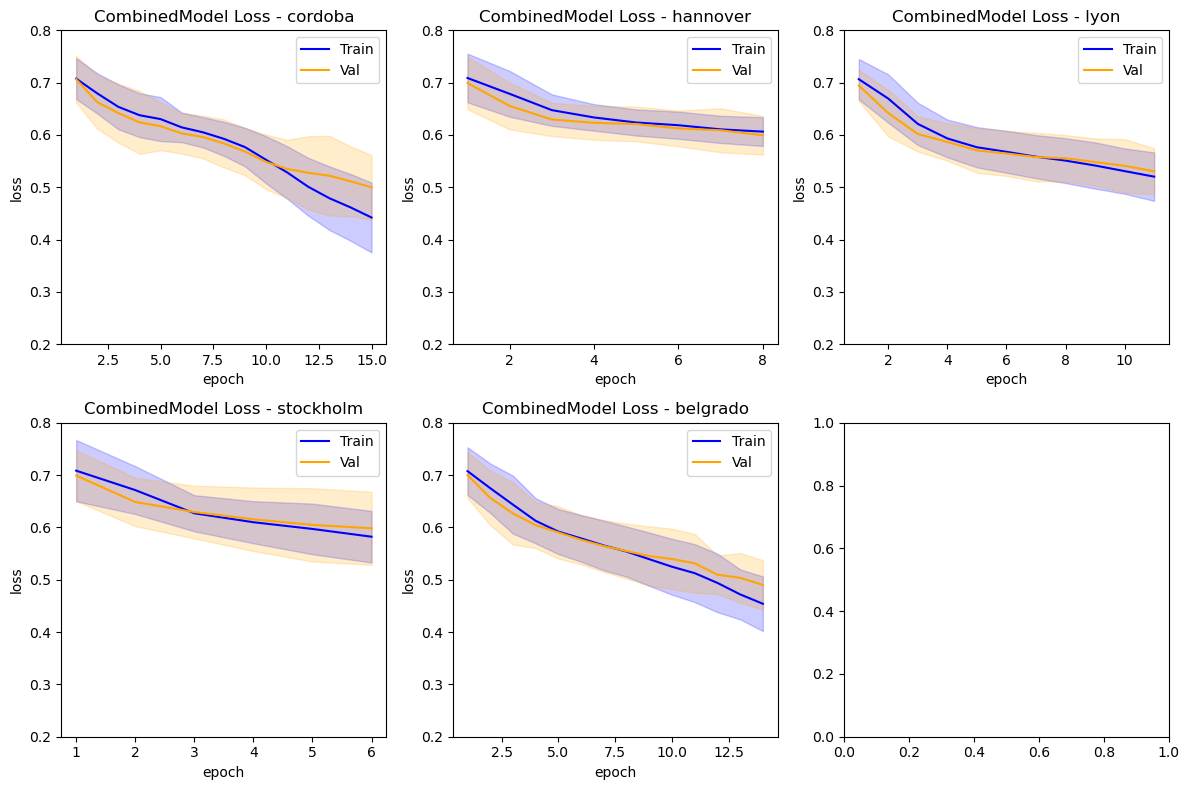

In [3]:
# Function to generate a fixed list of random seeds for reproducibility
def generate_ensemble_seeds(fixed_seed=123):
    rng = np.random.default_rng(fixed_seed)  # Create reproducible random number generator
    seeds = rng.integers(low=0, high=2**32 - 1, size=20).tolist()  # Generate 20 random seeds
    return seeds

# Generate list of seeds (same every run because of fixed_seed)
list_seeds = generate_ensemble_seeds(fixed_seed=123)

# Sites to evaluate
sites = ['cordoba','hannover','lyon' ,'stockholm','belgrado']

# Create subplot grid (2 rows x 3 columns) to plot training/validation losses per site
fig_site_loss, ax_site_loss = plt.subplots(2,3,figsize=(12,8))
ax_site_loss = ax_site_loss.flatten()  # Flatten for easy indexing

count_plot = 0  # Counter to track subplot index

# Loop over each site and aggregate results across seeds
for site in sites:

    losses_train_all_seeds = []  # Store training losses from all seeds
    losses_val_all_seeds = []    # Store validation losses from all seeds

    # Loop over seeds and load corresponding results
    for seed in list_seeds:

        # Path to the result files for this site and seed
        main_path = f'/path/of/results/files/members'
        with open(os.path.join(main_path, f'98p_results_data_{seed}.pkl'), 'rb') as f:
            seed_results = pickle.load(f)  # Load dictionary with loss histories
    
        # Extract training and validation loss curves
        loss_train = seed_results['losses_train']
        loss_val = seed_results['losses_val']
    
        losses_train_all_seeds.append(loss_train)  
        losses_val_all_seeds.append(loss_val)

    # Ensure all loss sequences have the same length by trimming to shortest run
    min_len = min([len(loss) for loss in losses_train_all_seeds])  
    train_losses_trimmed = np.array([loss[:min_len] for loss in losses_train_all_seeds])
    val_losses_trimmed = np.array([loss[:min_len] for loss in losses_val_all_seeds])
    
    # Compute mean and standard deviation across seeds for each epoch
    mean_train = train_losses_trimmed.mean(axis=0)
    std_train = train_losses_trimmed.std(axis=0)
    
    mean_val = val_losses_trimmed.mean(axis=0)
    std_val = val_losses_trimmed.std(axis=0)
    
    # Epoch indices (1-based)
    epochs = np.arange(1, min_len + 1)

    # Plot mean + uncertainty (std band) for training and validation losses
    ax_site_loss[count_plot].plot(epochs, mean_train, label='Train', color='blue')
    ax_site_loss[count_plot].fill_between(epochs, mean_train - std_train, mean_train + std_train, color='blue', alpha=0.2)
    ax_site_loss[count_plot].plot(epochs, mean_val, label='Val', color='orange')
    ax_site_loss[count_plot].fill_between(epochs, mean_val - std_val, mean_val + std_val, color='orange', alpha=0.2)
    
    # Add labels, title, legend, and axis limits
    ax_site_loss[count_plot].set_xlabel("epoch")
    ax_site_loss[count_plot].set_ylabel("loss")
    ax_site_loss[count_plot].set_title(f"CombinedModel Loss - {site}")
    ax_site_loss[count_plot].legend()
    ax_site_loss[count_plot].set_ylim(0.2, 0.8)  # Keep consistent y-limits for better comparison

    count_plot += 1  # Move to next subplot

# Output file name for the figure
name_save_losses_fig = "losses_all_locations_CombinedModel"
    
# Save figure in the specified folder
plot_save_path = "/your/path/to/save/figures/CombinedModel_losses"
plt.tight_layout()
plt.show()
os.makedirs(plot_save_path, exist_ok=True)  # Create directory if it does not exist
fig_site_loss.savefig(os.path.join(plot_save_path, f"95p_{name_save_losses_fig}.png"))
plt.close(fig_site_loss)  # Close figure to free memory


# Confusion matrices, accuracies and ROC curves

This block visualizes the **confusion matrices** for each site without applying any confidence-based filtering.  

- **Input:** Stored dictionaries containing the true and predicted labels for each location.  
- **Process:**  
  1. For each site, a confusion matrix is computed from the raw predictions.  
  2. The matrix is displayed as a heatmap with counts, percentages, and descriptive labels (*True Neg*, *False Pos*, etc.).  
  3. Text color is adjusted automatically for readability depending on cell intensity.  
- **Output:** A gri

Text(0.5, 0.98, 'Location Confusion matrices CombinedModel')

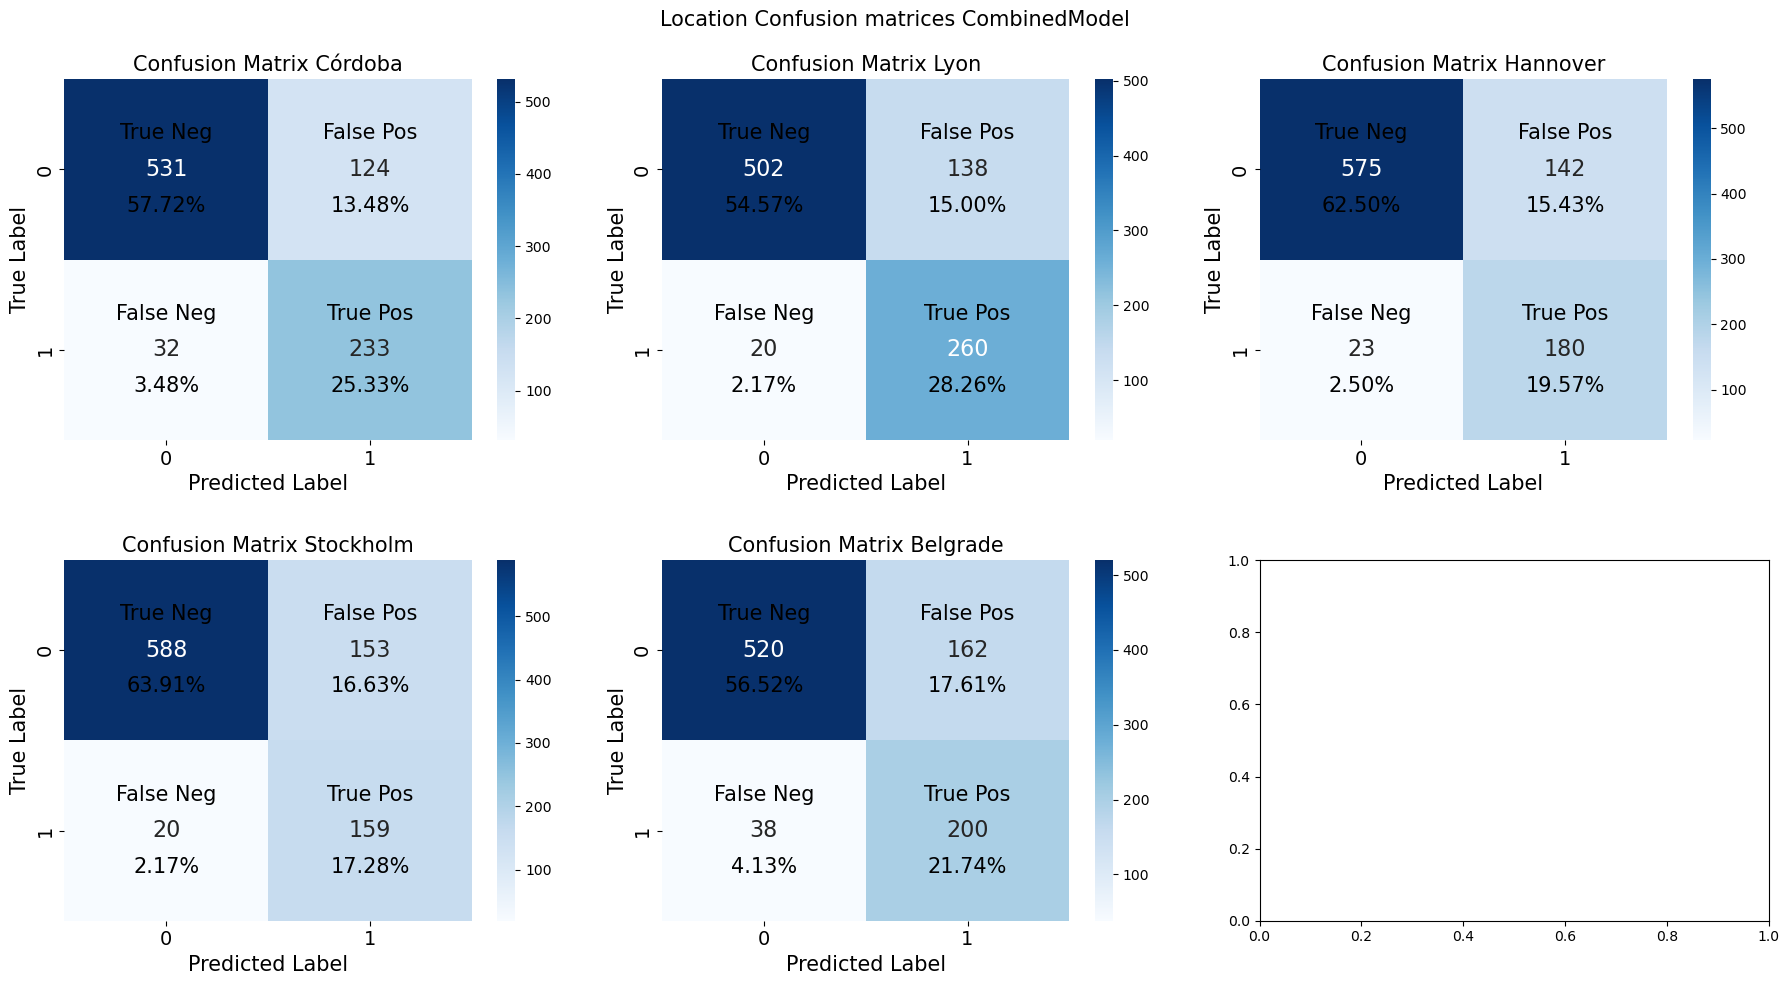

In [17]:
# Sites to evaluate (subset of all sites)
sites = ['cordoba','lyon','hannover','stockholm','belgrado']

sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Create subplot grid (2 rows x 3 columns) for confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten array for easy indexing

i = 0  # Counter for subplot index

number_lags = 3  # (Not used in this block, possibly relevant elsewhere)

# Loop through each site
for count_site, site in enumerate(sites):

    # Path to evaluation results
    main_path = '/path/to/ensamble/results/dictionary'

    # Load saved dictionary containing true/predicted labels
    with open(os.path.join(main_path, f'obs_TX_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)
    
    # Extract true and predicted labels
    y_true, y_pred = dict_results['y_true_pred_pairs']
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # Unpack values
    
    # Convert to percentages (for annotation later)
    total = np.sum(cm)
    cm_percentage = cm / total * 100
    
    # Plot confusion matrix as heatmap
    sns.heatmap(
        cm,
        annot=True,                # Show raw counts
        fmt='d',                   # Integer format
        cmap='Blues',              # Color scheme
        xticklabels=[0, 1],        # Labels for predicted axis
        yticklabels=[0, 1],        # Labels for true axis
        annot_kws={"size": 16},    # Font size for numbers
        ax=axes[i]
    )
    
    # Axis labels and title
    axes[i].set_xlabel("Predicted Label", fontsize=15)
    axes[i].set_ylabel("True Label", fontsize=15)
    axes[i].set_title(f"Confusion Matrix {sites_title[count_site]}", fontsize=15)
    axes[i].tick_params(axis='both', labelsize=14) 
    
    # Custom labels for matrix cells
    names = [["True Neg", "False Pos"], ["False Neg", "True Pos"]]
    values = [[tn, fp], [fn, tp]]
    
    # Add percentage and category labels on top of heatmap
    for m in range(2):
        for n in range(2):
            # Adjust text color based on background intensity
            if values[m][n] >= 650:
                color = 'white'
            else:
                color = 'black'
    
            # Percentage label
            axes[i].text(
                n + 0.5, m + 0.7,
                f"{cm_percentage[m, n]:.2f}%",
                ha="center", va="center",
                color=color, fontsize=15
            )
            # Category name (e.g., "True Pos")
            axes[i].text(
                n + 0.5, m + 0.3,
                names[m][n],
                ha="center", va="center",
                color=color, fontsize=15
            )

    i += 1  # Move to next subplot

# Adjust layout and add overall title
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=3)
plt.suptitle("Location Confusion matrices CombinedModel", fontsize=15)


## 25% most confident predictions

This block evaluates the model’s performance by plotting **confusion matrices** for each site, but only using the **most confident predictions**.  

- **Input:** Stored dictionaries with predicted labels, true labels, and class probabilities.  
- **Process:**  
  1. For each site, predictions are filtered to keep only the top `value%` most confident cases per class.  
  2. A confusion matrix is computed from the filtered predictions.  
  3. The matrix is plotted as a heatmap, showing both raw counts and percentages.  
  4. Cell annotations (e.g., *True Pos*, *False Neg*) are added for clarity.  
  5. Debugging info is printed to compare predictions before and after filtering.  
- **Output:** A grid of confusion matrices (2×3), one per site, annotated with percentages and class labels, plus a global title indicating the percentage of confident predictions used.  

Shape predicted before filtering: (920,)
Shape predicted after filtering: (460,)
Original number of extremes for cordoba before filtering: 357
Number of extremes for cordoba after filtering: 230
Shape predicted before filtering: (920,)
Shape predicted after filtering: (460,)
Original number of extremes for lyon before filtering: 398
Number of extremes for lyon after filtering: 230
Shape predicted before filtering: (920,)
Shape predicted after filtering: (460,)
Original number of extremes for hannover before filtering: 322
Number of extremes for hannover after filtering: 230
Shape predicted before filtering: (920,)
Shape predicted after filtering: (460,)
Original number of extremes for stockholm before filtering: 312
Number of extremes for stockholm after filtering: 230
Shape predicted before filtering: (920,)
Shape predicted after filtering: (460,)
Original number of extremes for belgrado before filtering: 362
Number of extremes for belgrado after filtering: 230


Text(0.5, 0.98, 'Confusions matrices CombinedModel using 50% most confident predictions')

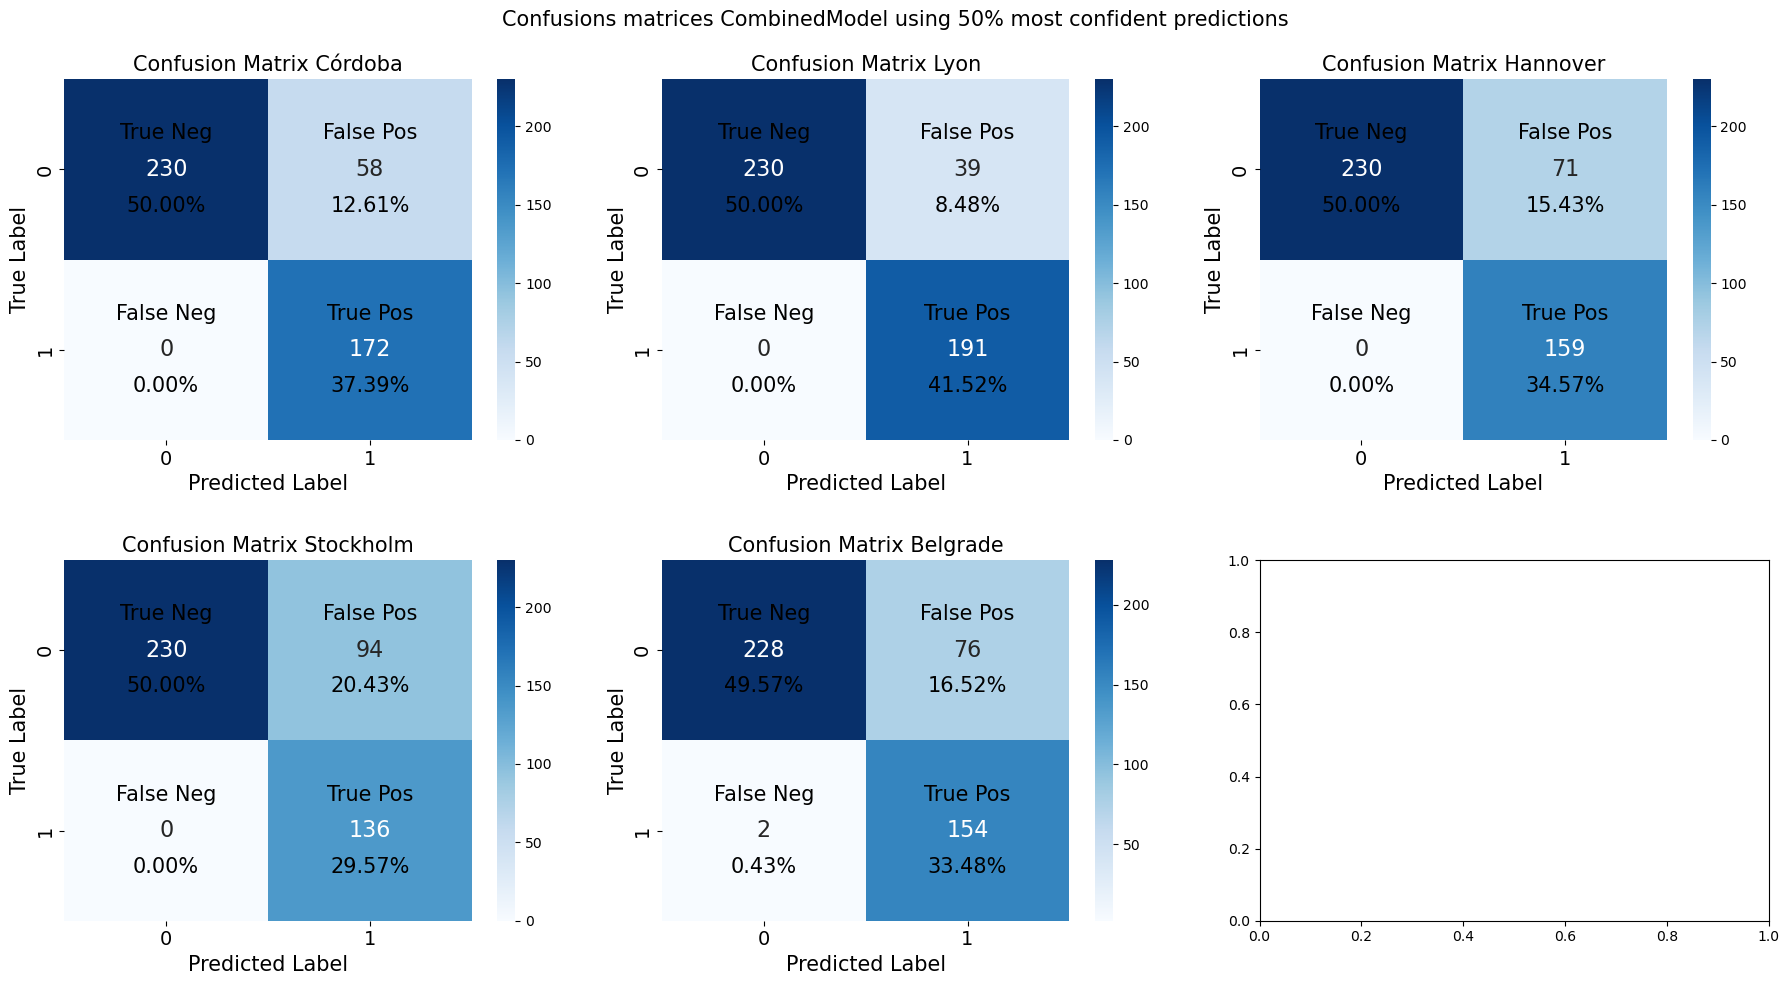

In [18]:
# Sites to evaluate
sites = ['cordoba','lyon','hannover','stockholm','belgrado']

# Titles for plots (same order as `sites`)
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade']

# ------------------------------------------------------------------------------------------------------
# Confusion Matrix plot with filtering by prediction confidence
# ------------------------------------------------------------------------------------------------------

# Create subplot grid (2 rows x 3 columns) for confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

i = 0  # Counter for subplot index

# Loop through each site
for count_site, site in enumerate(sites):

    # Path to evaluation results
    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'

    # Load saved dictionary containing probabilities and predictions
    with open(os.path.join(main_path, f'obs_TX_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)
  
    out_probabilities = dict_results['out_probs_sites']  # Model-predicted probabilities
    
    # --------------------------------------------------------------------------------------------------
    # Filter predictions: keep only the top % most confident predictions
    # --------------------------------------------------------------------------------------------------
    
    mask = np.zeros_like(out_probabilities, dtype=bool)  # Initialize mask (same shape as probs)

    value = 25  # Keep top `value%` for each class (so 50% total retained)

    # For each class column in the probability array
    for j in range(out_probabilities.shape[1]):
        # Compute threshold as the (100 - value)th percentile
        threshold = np.percentile(out_probabilities[:, j], 100 - value)
        # Mark predictions above this threshold
        mask[:, j] = out_probabilities[:, j] >= threshold
    
    # Combine masks across classes (keep if confident in either class 0 or 1)
    mask_def = mask[:,0] | mask[:,1]
        
    # Extract true and predicted labels
    y_true, y_pred = dict_results['y_true_pred_pairs']    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Apply filtering mask
    y_true_filtered = y_true[mask_def]
    y_pred_filtered = y_pred[mask_def]
    
    # Balanced accuracy metric after filtering (accounts for class imbalance)
    balanced_accuracy = balanced_accuracy_score(y_true_filtered, y_pred_filtered)

    # Compute confusion matrix using filtered predictions
    cm = confusion_matrix(y_true_filtered, y_pred_filtered)
    tn, fp, fn, tp = cm.ravel()
    
    # Convert confusion matrix counts to percentages
    total = np.sum(cm)
    cm_percentage = cm / total * 100
    
    # Plot confusion matrix as heatmap
    sns.heatmap(
        cm,
        annot=True,                # Show raw counts
        fmt='d',                   # Integer format
        cmap='Blues',              # Color scheme
        xticklabels=[0, 1],        # Labels for predicted axis
        yticklabels=[0, 1],        # Labels for true axis
        annot_kws={"size": 16},    # Font size for numbers
        ax=axes[i]
    )
    
    # Axis labels and title
    axes[i].set_xlabel("Predicted Label", fontsize=15)
    axes[i].set_ylabel("True Label", fontsize=15)
    axes[i].set_title(f"Confusion Matrix {sites_title[count_site]}", fontsize=15)
    axes[i].tick_params(axis='both', labelsize=14) 
    
    # Custom labels for matrix cells
    names = [["True Neg", "False Pos"], ["False Neg", "True Pos"]]
    values = [[tn, fp], [fn, tp]]
    
    # Add percentage and category labels on top of heatmap
    for m in range(2):
        for n in range(2):
            # Adjust text color based on cell intensity
            if values[m][n] >= 650:
                color = 'white'
            else:
                color = 'black'
    
            # Percentage label
            axes[i].text(
                n + 0.5, m + 0.7,
                f"{cm_percentage[m, n]:.2f}%",
                ha="center", va="center",
                color=color, fontsize=15
            )
            # Category name (e.g., "True Pos")
            axes[i].text(
                n + 0.5, m + 0.3,
                names[m][n],
                ha="center", va="center",
                color=color, fontsize=15
            )
    
    i += 1  # Move to next subplot
    
    # Print debugging information about filtering effect
    print(f"Shape predicted before filtering: {y_pred.shape}")
    print(f"Shape predicted after filtering: {y_pred_filtered.shape}")
    print(f"Original number of extremes for {site} before filtering: {(y_pred==1).sum()}")
    print(f"Number of extremes for {site} after filtering: {(y_pred_filtered==1).sum()}")

# Adjust layout and add global title
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=3)
plt.suptitle(f"Confusions matrices CombinedModel using {value*2}% most confident predictions", fontsize=15)


## Class accuracy as a function of % most confident predictions 

This block computes and plots how the **balanced accuracy (BA)**, **extreme event accuracy (EA)**, and **non-extreme event accuracy (NEA)** vary across different confidence thresholds for each site.  

- **Input:** Pre-computed dictionaries containing model predictions and class probabilities for each location.  
- **Process:**  
  1. For each site and confidence threshold, predictions are filtered to keep only the most confident cases.  
  2. Class-specific accuracies (extreme = class 1, non-extreme = class 0) and balanced accuracy are computed.  
  3. Results are plotted side-by-side across locations for comparison.  
- **Output:** A grid of plots (2×3), one per site, showing BA, EA, and NEA as functions of the confidence threshold.  

cordoba
Extreme accuracy : (96.8 + 1.8 )%
Non-Extreme accuracy : (62.2 + 3.2 )%
Balanced accuracy : (79.5 + 2.5)%
lyon
Extreme accuracy : (100.0 + 0.0 )%
Non-Extreme accuracy : (66.5 + 3.1 )%
Balanced accuracy : (83.2 + 1.6)%
hannover
Extreme accuracy : (100.0 + 0.0 )%
Non-Extreme accuracy : (59.0 + 3.2 )%
Balanced accuracy : (79.5 + 1.6)%
stockholm
Extreme accuracy : (55.3 + 7.3 )%
Non-Extreme accuracy : (89.1 + 1.2 )%
Balanced accuracy : (72.2 + 4.2)%
belgrado
Extreme accuracy : (100.0 + 0.0 )%
Non-Extreme accuracy : (54.5 + 3.3 )%
Balanced accuracy : (77.3 + 1.6)%
marrakech
Extreme accuracy : (96.7 + 2.3 )%
Non-Extreme accuracy : (57.0 + 3.2 )%
Balanced accuracy : (76.8 + 2.8)%


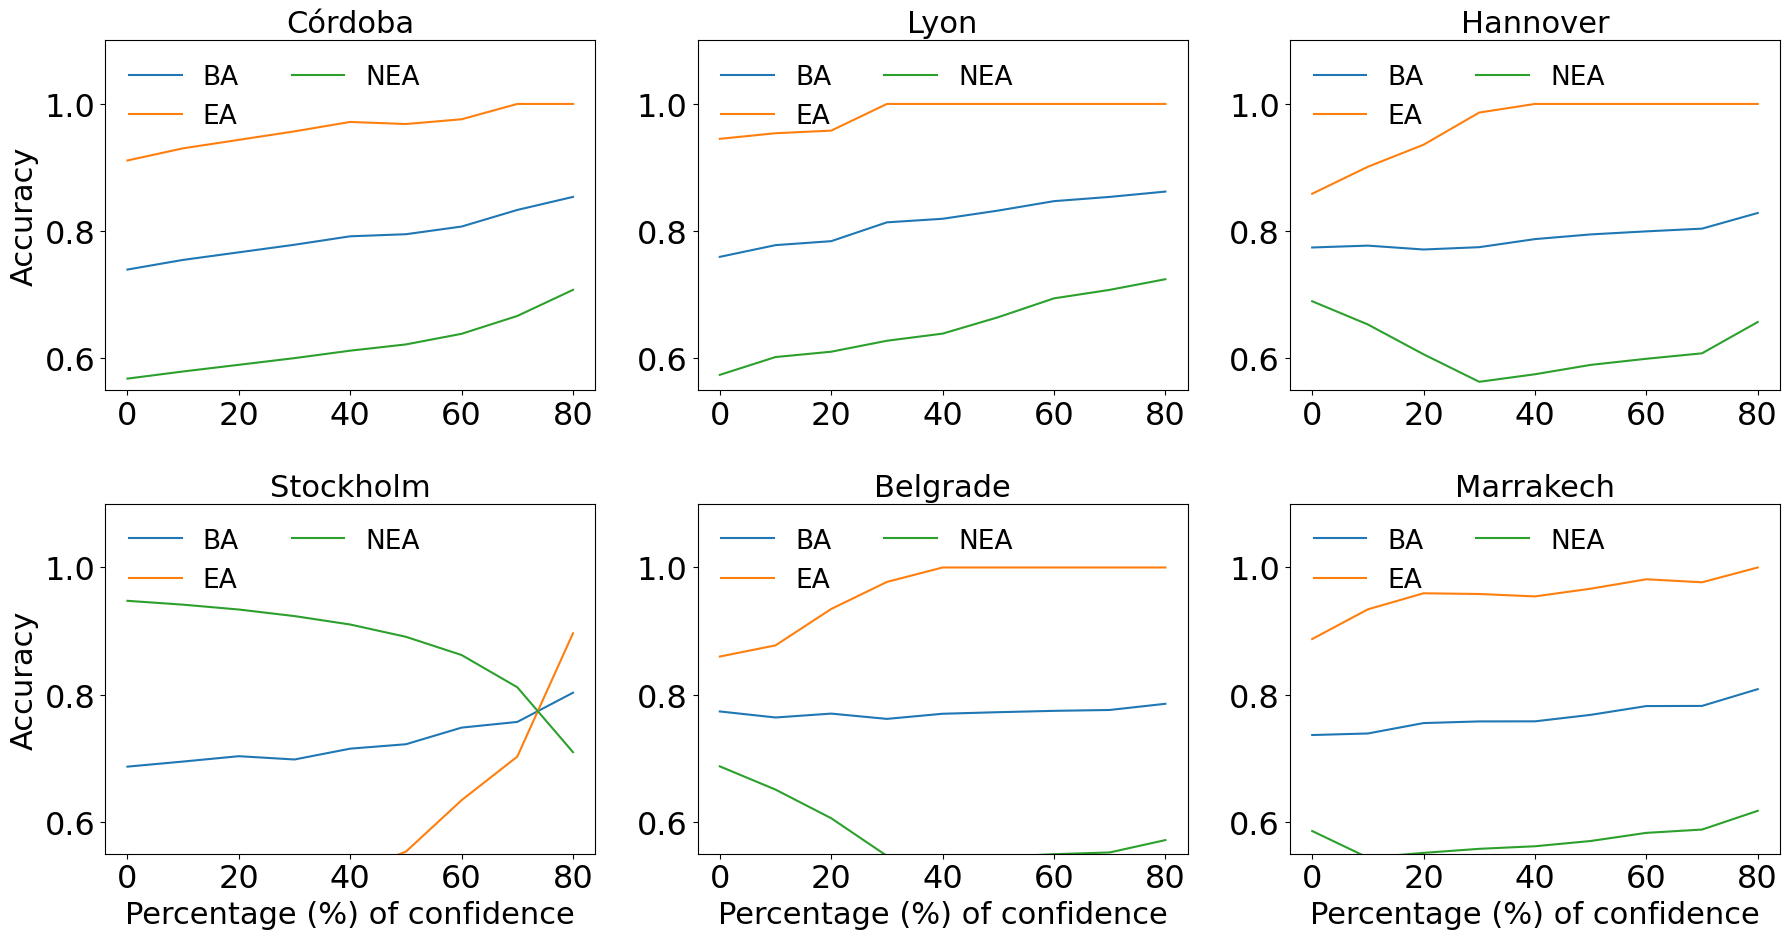

In [5]:
# ------------------------------------------------------------------------------------------------------
# Plot accuracies (Balanced, Extreme, Non-Extreme) vs. confidence thresholds for multiple locations
# ------------------------------------------------------------------------------------------------------

# Create subplot grid (2 rows x 3 columns) to show each site
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Sites to evaluate
sites = ['cordoba','lyon','hannover','stockholm','belgrado','marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

number_lags = 3  # (Not directly used here, but included in save filename)

# Confidence thresholds (percentiles) to test
percentages = [50, 55, 60, 65, 70, 75, 80, 85, 90]

j = 0  # Subplot index counter
    
# Loop over each site
for count_site, site in enumerate(sites):

    main_path = '/you/path/to/dictionary/ensamble_results/'

    # Load saved dictionary with predictions and probabilities
    with open(os.path.join(main_path, f'98p_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)

    # Lists to store results across thresholds
    extreme_accuracies = []
    nonextreme_accuracies = []
    balanced_acc = []

    # Loop over different confidence thresholds
    for value in percentages: 

        out_probabilities = dict_results['out_probs_sites']  # Model probabilities per class
        
        # ----------------------------------------------------------------------------------------------
        # Build mask: keep only predictions above chosen confidence percentile
        # ----------------------------------------------------------------------------------------------
        mask = np.zeros_like(out_probabilities, dtype=bool)
        
        for i in range(out_probabilities.shape[1]):
            threshold = np.percentile(out_probabilities[:, i], value)
            mask[:, i] = out_probabilities[:, i] >= threshold
        
        # Final mask: True if confident in either class (0 or 1)
        mask_def = mask[:,0] | mask[:,1]
        
        # Extract labels and predictions
        y_true, y_pred = dict_results['y_true_pred_pairs']
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        
        # Apply filtering
        y_true_filtered = y_true[mask_def]
        y_pred_filtered = y_pred[mask_def]
        
        # Balanced accuracy (averages class-specific accuracies)
        balanced_accuracy = balanced_accuracy_score(y_true_filtered, y_pred_filtered)
        
        # ----------------------------------------------------------------------------------------------
        # Compute per-class accuracies (Extreme = class 1, Non-extreme = class 0)
        # ----------------------------------------------------------------------------------------------
        total_extreme = (y_true_filtered == 1).sum()
        total_nonextreme = (y_true_filtered == 0).sum()
        
        extreme_acc = ((y_pred_filtered == y_true_filtered) & (y_pred_filtered == 1)).sum() / total_extreme
        error_extreme = np.sqrt(extreme_acc * (1 - extreme_acc) / total_extreme) 
        
        nonextreme_acc = ((y_pred_filtered == y_true_filtered) & (y_pred_filtered == 0)).sum() / total_nonextreme
        error_nonextreme = np.sqrt(extreme_acc * (1 - nonextreme_acc) / total_nonextreme) 

        # Balanced accuracy error estimate (average of per-class errors)
        error_balanced_acc = 0.5 * (error_extreme + error_nonextreme) 
        
        # Store results
        extreme_accuracies.append(extreme_acc)
        nonextreme_accuracies.append(nonextreme_acc)
        balanced_acc.append(balanced_accuracy)

        # Print summary at 75% threshold
        if value == 75:
            print(site)
            print(f"Extreme accuracy : ({extreme_acc*100:.1f} + {error_extreme*100:.1f} )%")
            print(f"Non-Extreme accuracy : ({nonextreme_acc*100:.1f} + {error_nonextreme*100:.1f} )%")
            print(f"Balanced accuracy : ({balanced_accuracy*100:.1f} + {error_balanced_acc*100:.1f})%")
    
    # ----------------------------------------------------------------------------------------------
    # Plot results for this site
    # ----------------------------------------------------------------------------------------------
    axes[j].plot((np.array(percentages) - 50) * 2, np.array(balanced_acc), label="BA")
    axes[j].plot((np.array(percentages) - 50) * 2, np.array(extreme_accuracies), label="EA")
    axes[j].plot((np.array(percentages) - 50) * 2, np.array(nonextreme_accuracies), label="NEA")
    
    axes[j].set_title(sites_title[count_site], fontsize=22)
    axes[j].tick_params(axis='both', labelsize=23) 
    axes[j].legend(frameon=False, loc="upper left", fontsize=19, ncol=2)
    axes[j].set_ylim(0.55, 1.1)
    j += 1

# ----------------------------------------------------------------------------------------------
# Global formatting
# ----------------------------------------------------------------------------------------------
for m in range(3, 6):  # Bottom row x-axis labels
    axes[m].set_xlabel("Percentage (%) of confidence", fontsize=22)

axes[0].set_ylabel("Accuracy", fontsize=22)
axes[3].set_ylabel("Accuracy", fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=3)

# Save figure to output path
plt.savefig(f"/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/Accuracies/98p_accuracies_locations_Combinedmodel_{number_lags}lags.png")


## ROC curve as a function of percentage of confidance 

This block generates **ROC curves** (Receiver Operating Characteristic) for each site, showing how the model distinguishes between extremes (positive class) and non-extremes (negative class).  

- **Input:** Model probabilities and predictions per site, stored in dictionaries.  
- **Process:**  
  1. For each site, predictions are filtered at multiple confidence thresholds.  
  2. ROC curves are computed using the true labels and predicted probabilities.  
  3. Each threshold is plotted in a different shade of blue (higher confidence → darker).  
  4. The 0.5 cutoff point is highlighted on each curve.  
- **Output:** A grid of ROC curves (2×3), one per site, with multiple curves per site corresponding to different confidence levels.  

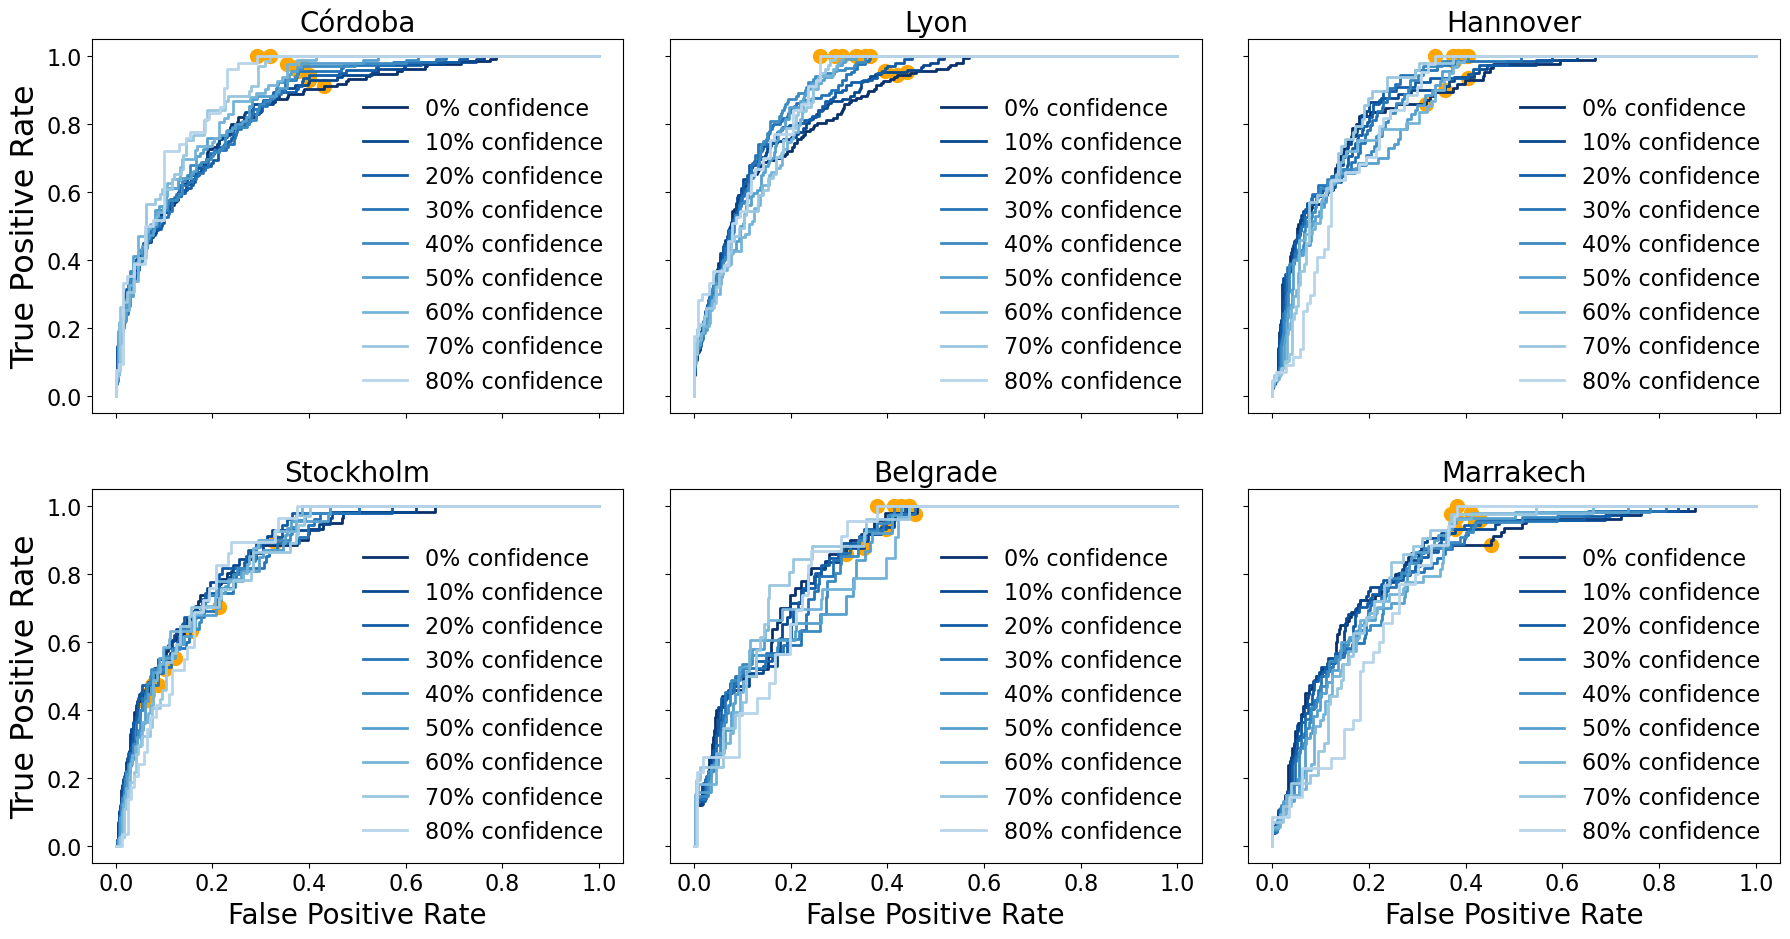

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.cm as cm

number_lags = 3  # (used in figure save name)

# Sites to evaluate
sites = ['cordoba','lyon','hannover','stockholm','belgrado','marrakech']
sites_title = ['Córdoba', 'Lyon', 'Hannover', 'Stockholm', 'Belgrade', 'Marrakech']

# Confidence thresholds (percentiles) to test
percentages = [50, 55, 60, 65, 70, 75, 80, 85, 90]

# ------------------------------------------------------------------------------------------
# Build color map for confidence levels (higher confidence → darker blue)
# ------------------------------------------------------------------------------------------
norm = np.linspace(1, 0.3, len(percentages))   # Scale values for colormap
colors = [cm.Blues(n) for n in norm]           # Generate color shades
percentage_color_map = dict(zip(percentages, colors))  # Map each percentile to a color

# ------------------------------------------------------------------------------------------
# Create subplot grid for ROC curves (2 rows × 3 columns, shared axes for comparability)
# ------------------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex='col', sharey='row')
axes = axes.flatten()

j = 0  # Subplot index counter
    
# Loop over each site
for count_site, site in enumerate(sites):

    main_path = '/home/bsc/bsc167965/TFM/ML/dictionaries_evaluation/'

    # Load stored predictions and probabilities
    with open(os.path.join(main_path, f'98p_results_data_{site}.pkl'), 'rb') as f:
        dict_results = pickle.load(f)

    # --------------------------------------------------------------------------------------
    # Loop over different confidence thresholds
    # --------------------------------------------------------------------------------------
    for value in percentages: 

        out_probabilities = dict_results['out_probs_sites']  # Probabilities per class
        
        # Build mask: keep only samples above the selected confidence threshold
        mask = np.zeros_like(out_probabilities, dtype=bool)
        
        for i in range(out_probabilities.shape[1]):
            threshold = np.percentile(out_probabilities[:, i], value)
            mask[:, i] = out_probabilities[:, i] >= threshold
        
        mask_def = mask[:,0] | mask[:,1]  # Keep if confident in either class (0 or 1)
        
        # Extract true and predicted labels
        y_true, y_pred = dict_results['y_true_pred_pairs']
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        
        # Apply filtering
        y_true_filtered = y_true[mask_def]
        y_pred_filtered = y_pred[mask_def]
    
        # ----------------------------------------------------------------------------------
        # Compute ROC curve and AUC (area under curve)
        # ----------------------------------------------------------------------------------
        fpr, tpr, thresholds = roc_curve(
            y_true_filtered,
            out_probabilities[:, 1][mask_def]  # Probabilities for positive class
        )
        roc_auc = auc(fpr, tpr)  # AUC = overall discriminative ability

        # Plot ROC curve for this confidence level
        axes[j].plot(
            fpr, tpr,
            color=percentage_color_map[value],
            lw=2,
            label=f"{(value-50)*2}% confidence"
        )

        # Highlight cutoff point (threshold ≈ 0.5)
        cutoff = 0.5
        index = (np.abs(thresholds - cutoff)).argmin()  
        axes[j].scatter(
            fpr[index], tpr[index],
            marker='o' if cutoff == 0.5 else '^', 
            color='orange', s=100
        )

        # Debug output (unused since value never equals 25 in this loop)
        if value == 25:
            print(site)
            print(roc_auc)
    
    # --------------------------------------------------------------------------------------
    # Format subplot
    # --------------------------------------------------------------------------------------
    axes[j].set_title(sites_title[count_site], fontsize=20)
    axes[j].tick_params(axis='both', labelsize=16) 
    axes[j].legend(frameon=False, loc="lower right", fontsize=16)
    
    j += 1

# ------------------------------------------------------------------------------------------
# Global labels and layout
# ------------------------------------------------------------------------------------------
for m in range(3, 6):  # Bottom row x-axis labels
    axes[m].set_xlabel('False Positive Rate', fontsize=20)

axes[0].set_ylabel('True Positive Rate', fontsize=23)
axes[3].set_ylabel('True Positive Rate', fontsize=23)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3, w_pad=3)

# Save ROC curves figure
plt.savefig(f"/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/ROC_curve/95p_ROC_curves_Combinedmodel_{number_lags}lags.png")
